<a href="https://colab.research.google.com/github/Alaa-Boghdady/Chronic-Kidney-Disease-Classification/blob/main/Kidney_Disease_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Chronic Kidney Disease Prediction**



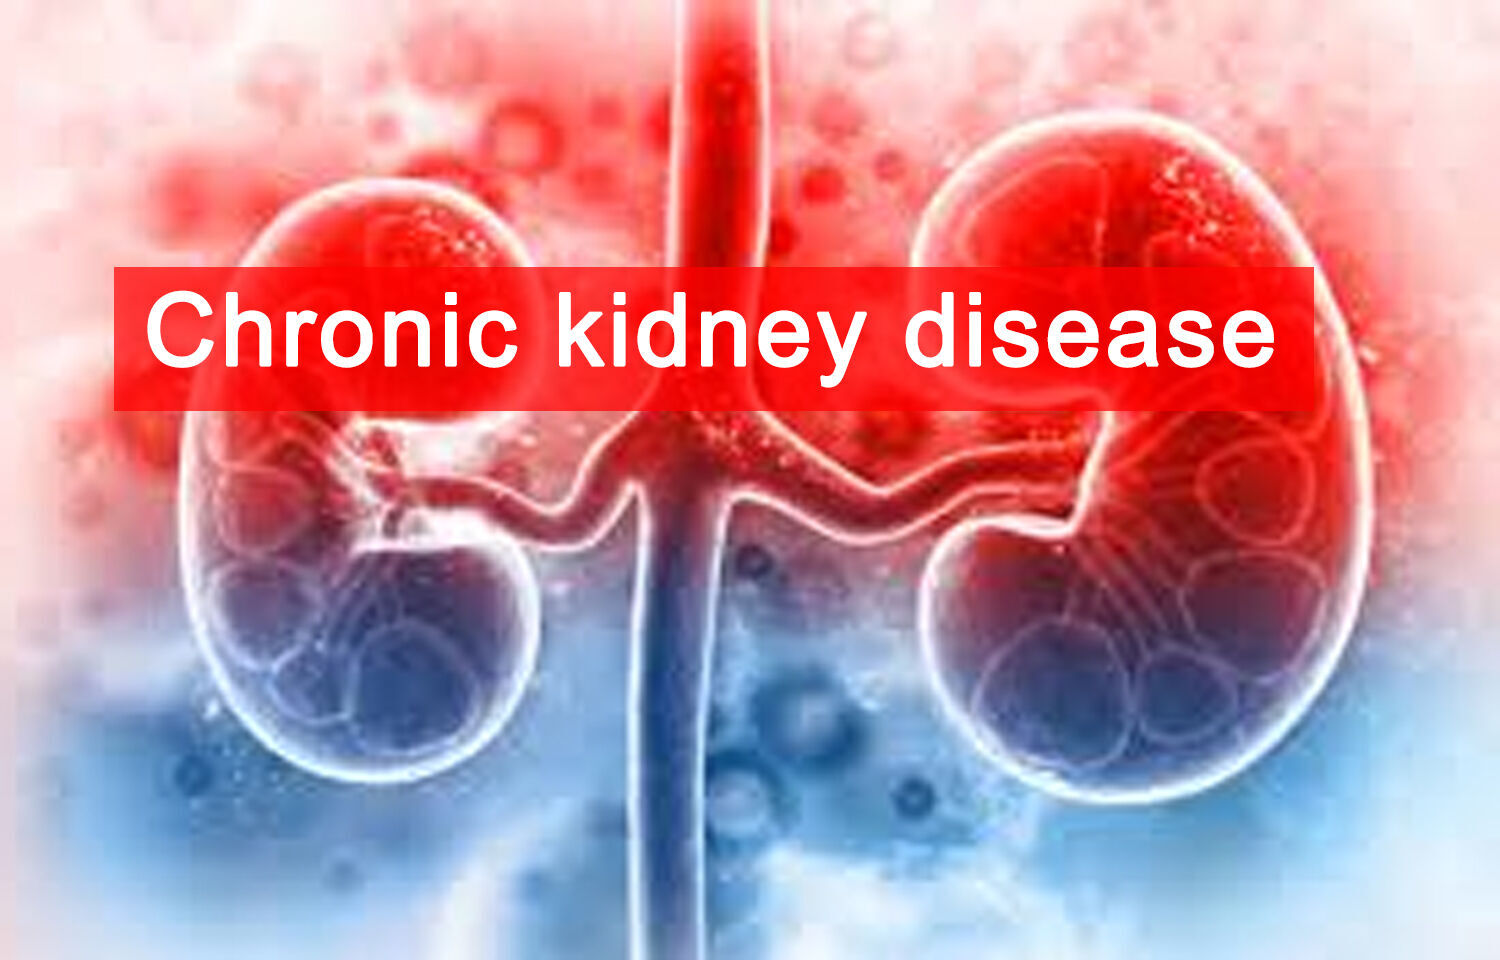

Table of Contents :


*   EDA
*   Data Preprocessing
*   Feature Encoding
*   Model Building :

     KNN

     Decision Tree classifier

     Random forest classifier

     Ada Boost classifier

*   Model Comparison

















In [ ]:
## Necessary Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

import warnings
warnings.filterwarnings("ignore")

plt.style.use("fivethirtyeight")
%matplotlib inline
pd.set_option("display.max_columns" , 26)

In [ ]:
#loading the data
df = pd.read_csv("/content/kidney_disease.csv" , sep ="," , encoding="latin-1")

In [ ]:
df.head()

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,bu,sc,sod,pot,hemo,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,36.0,1.2,NaN,NaN,15.4,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,18.0,0.8,NaN,NaN,11.3,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,53.0,1.8,NaN,NaN,9.6,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,56.0,3.8,111.0,2.5,11.2,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,26.0,1.4,NaN,NaN,11.6,35,7300,4.6,no,no,no,good,no,no,ckd


In [ ]:
df.shape

(400, 26)

In [ ]:
#Droping id column
df.drop("id" , axis=1 , inplace=True)

Age: العمر

Blood Pressure: ضغط الدم

Specific Gravity: الجاذبية النوعية

Albumin: الألبومين

Sugar:السكر

Red Blood Cells: خلايا الدم الحمراء

Pus Cell: خلايا الصديد

Pus Cell Clumps: كتل خلايا الصديد

Bacteria: البكتيريا

Blood Glucose Random: سكر الدم العشوائي

Blood Urea: اليوريا في الدم

Serum Creatinine: الكرياتينين في المصل

Sodium: الصوديوم

Potassium: البوتاسيوم

Haemoglobin: الهيموجلوبين

Packed Cell Volume: حجم الخلايا المعبأة

White Blood Cell Count: عدد خلايا الدم البيضاء

Red Blood Cell Count: عدد خلايا الدم الحمراء

Hypertension: ارتفاع ضغط الدم

Diabetes Mellitus: داء السكري

Coronary Artery Disease: مرض الشريان التاجي

Appetite: الشهية

Pedal Edema: الوذمة في القدم

Aanemia: فقر الدم

Class: الفئة


In [ ]:
#rename the columns
df.columns = ["Age" , "Blood_Pressure" , "Specific_Gravity" , "Albumin" , "Sugar" , "Red_blood_cells" , "Pus_cell" ,   'Pus_cell_clumps', 'Bacteria', 'Blood_glucose_random', 'Blood_urea', 'Serum_creatinine', 'Sodium',
              'Potassium', 'Haemoglobin', 'Packed_cell_volume', 'White_blood_cell_count', 'Red_blood_cell_count',
              'Hypertension', 'Diabetes_mellitus', 'Coronary_artery_disease', 'Appetite', 'Peda_edema',
              'Aanemia', 'Class']

In [ ]:
df.head()

,Age,Blood_Pressure,Specific_Gravity,Albumin,Sugar,Red_blood_cells,Pus_cell,Pus_cell_clumps,Bacteria,Blood_glucose_random,Blood_urea,Serum_creatinine,Sodium,Potassium,Haemoglobin,Packed_cell_volume,White_blood_cell_count,Red_blood_cell_count,Hypertension,Diabetes_mellitus,Coronary_artery_disease,Appetite,Peda_edema,Aanemia,Class
0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,36.0,1.2,NaN,NaN,15.4,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,18.0,0.8,NaN,NaN,11.3,38,6000,NaN,no,no,no,good,no,no,ckd
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,53.0,1.8,NaN,NaN,9.6,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,56.0,3.8,111.0,2.5,11.2,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,26.0,1.4,NaN,NaN,11.6,35,7300,4.6,no,no,no,good,no,no,ckd


In [ ]:
df.columns

Index(['Age', 'Blood_Pressure', 'Specific_Gravity', 'Albumin', 'Sugar',
       'Red_blood_cells', 'Pus_cell', 'Pus_cell_clumps', 'Bacteria',
       'Blood_glucose_random', 'Blood_urea', 'Serum_creatinine', 'Sodium',
       'Potassium', 'Haemoglobin', 'Packed_cell_volume',
       'White_blood_cell_count', 'Red_blood_cell_count', 'Hypertension',
       'Diabetes_mellitus', 'Coronary_artery_disease', 'Appetite',
       'Peda_edema', 'Aanemia', 'Class'],
      dtype='object')

In [ ]:
df.describe()
#there is a few outliers

,Age,Blood_Pressure,Specific_Gravity,Albumin,Sugar,Blood_glucose_random,Blood_urea,Serum_creatinine,Sodium,Potassium,Haemoglobin
count,391.000000,388.000000,353.000000,354.000000,351.000000,356.000000,381.000000,383.000000,313.000000,312.000000,348.000000
mean,51.483376,76.469072,1.017408,1.016949,0.450142,148.036517,57.425722,3.072454,137.528754,4.627244,12.526437
std,17.169714,13.683637,0.005717,1.352679,1.099191,79.281714,50.503006,5.741126,10.408752,3.193904,2.912587
min,2.000000,50.000000,1.005000,0.000000,0.000000,22.000000,1.500000,0.400000,4.500000,2.500000,3.100000
25%,42.000000,70.000000,1.010000,0.000000,0.000000,99.000000,27.000000,0.900000,135.000000,3.800000,10.300000
50%,55.000000,80.000000,1.020000,0.000000,0.000000,121.000000,42.000000,1.300000,138.000000,4.400000,12.650000
75%,64.500000,80.000000,1.020000,2.000000,0.000000,163.000000,66.000000,2.800000,142.000000,4.900000,15.000000
max,90.000000,180.000000,1.025000,5.000000,5.000000,490.000000,391.000000,76.000000,163.000000,47.000000,17.800000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      391 non-null    float64
 1   Blood_Pressure           388 non-null    float64
 2   Specific_Gravity         353 non-null    float64
 3   Albumin                  354 non-null    float64
 4   Sugar                    351 non-null    float64
 5   Red_blood_cells          248 non-null    object 
 6   Pus_cell                 335 non-null    object 
 7   Pus_cell_clumps          396 non-null    object 
 8   Bacteria                 396 non-null    object 
 9   Blood_glucose_random     356 non-null    float64
 10  Blood_urea               381 non-null    float64
 11  Serum_creatinine         383 non-null    float64
 12  Sodium                   313 non-null    float64
 13  Potassium                312 non-null    float64
 14  Haemoglobin              3

In [ ]:
#As we can see that 'packed_cell_volume', 'white_blood_cell_count' and 'red_blood_cell_count' are object type. We need to change them to numerical dtype.
## converting necessary columns to numerical type
df["Packed_cell_volume"] = pd.to_numeric(df["Packed_cell_volume"] , errors="coerce")
df["White_blood_cell_count"] = pd.to_numeric(df["White_blood_cell_count"] , errors="coerce")
df["Red_blood_cell_count"]=pd.to_numeric(df["Red_blood_cell_count"] , errors="coerce")

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      391 non-null    float64
 1   Blood_Pressure           388 non-null    float64
 2   Specific_Gravity         353 non-null    float64
 3   Albumin                  354 non-null    float64
 4   Sugar                    351 non-null    float64
 5   Red_blood_cells          248 non-null    object 
 6   Pus_cell                 335 non-null    object 
 7   Pus_cell_clumps          396 non-null    object 
 8   Bacteria                 396 non-null    object 
 9   Blood_glucose_random     356 non-null    float64
 10  Blood_urea               381 non-null    float64
 11  Serum_creatinine         383 non-null    float64
 12  Sodium                   313 non-null    float64
 13  Potassium                312 non-null    float64
 14  Haemoglobin              3

In [ ]:
# Extracting categorical and numerical columns
cat_cols=[col for col in df.columns if df[col].dtype=="object"]
num_cols=[col for col in df.columns if df[col].dtype!="object"]

In [ ]:
# looking at unique values in categorical columns
for col in cat_cols:
  print(f"{col} has {df[col].unique()} values\n")

Red_blood_cells has [nan 'normal' 'abnormal'] values

Pus_cell has ['normal' 'abnormal' nan] values

Pus_cell_clumps has ['notpresent' 'present' nan] values

Bacteria has ['notpresent' 'present' nan] values

Hypertension has ['yes' 'no' nan] values

Diabetes_mellitus has ['yes' 'no' ' yes' '\tno' '\tyes' nan] values

Coronary_artery_disease has ['no' 'yes' '\tno' nan] values

Appetite has ['good' 'poor' nan] values

Peda_edema has ['no' 'yes' nan] values

Aanemia has ['no' 'yes' nan] values

Class has ['ckd' 'ckd\t' 'notckd'] values



In [ ]:
#There is some ambugity present in the columns we have to remove that.
#replace incorrect values
df["Diabetes_mellitus"].replace(to_replace={"\tyes" : "yes" , "\tno": "no" , ' yes':"yes" } , inplace=True)
df["Coronary_artery_disease"] = df["Coronary_artery_disease"].replace(to_replace="\tno" , value="no")
df["Class"] = df["Class"].replace(to_replace={"ckd\t" :"ckd" , "notckd" : "not ckd"})

In [ ]:
df["Class"]=df["Class"].map({"ckd":0 , "not ckd" : 1})
df["Class"]=pd.to_numeric(df["Class"], errors="coerce")

In [ ]:
cols = ["Diabetes_mellitus" , "Coronary_artery_disease" , "Class"]
for col in cols:
  print(f"{col} has {df[col]. unique()} values\n")

Diabetes_mellitus has ['yes' 'no' nan] values

Coronary_artery_disease has ['no' 'yes' nan] values

Class has [0 1] values



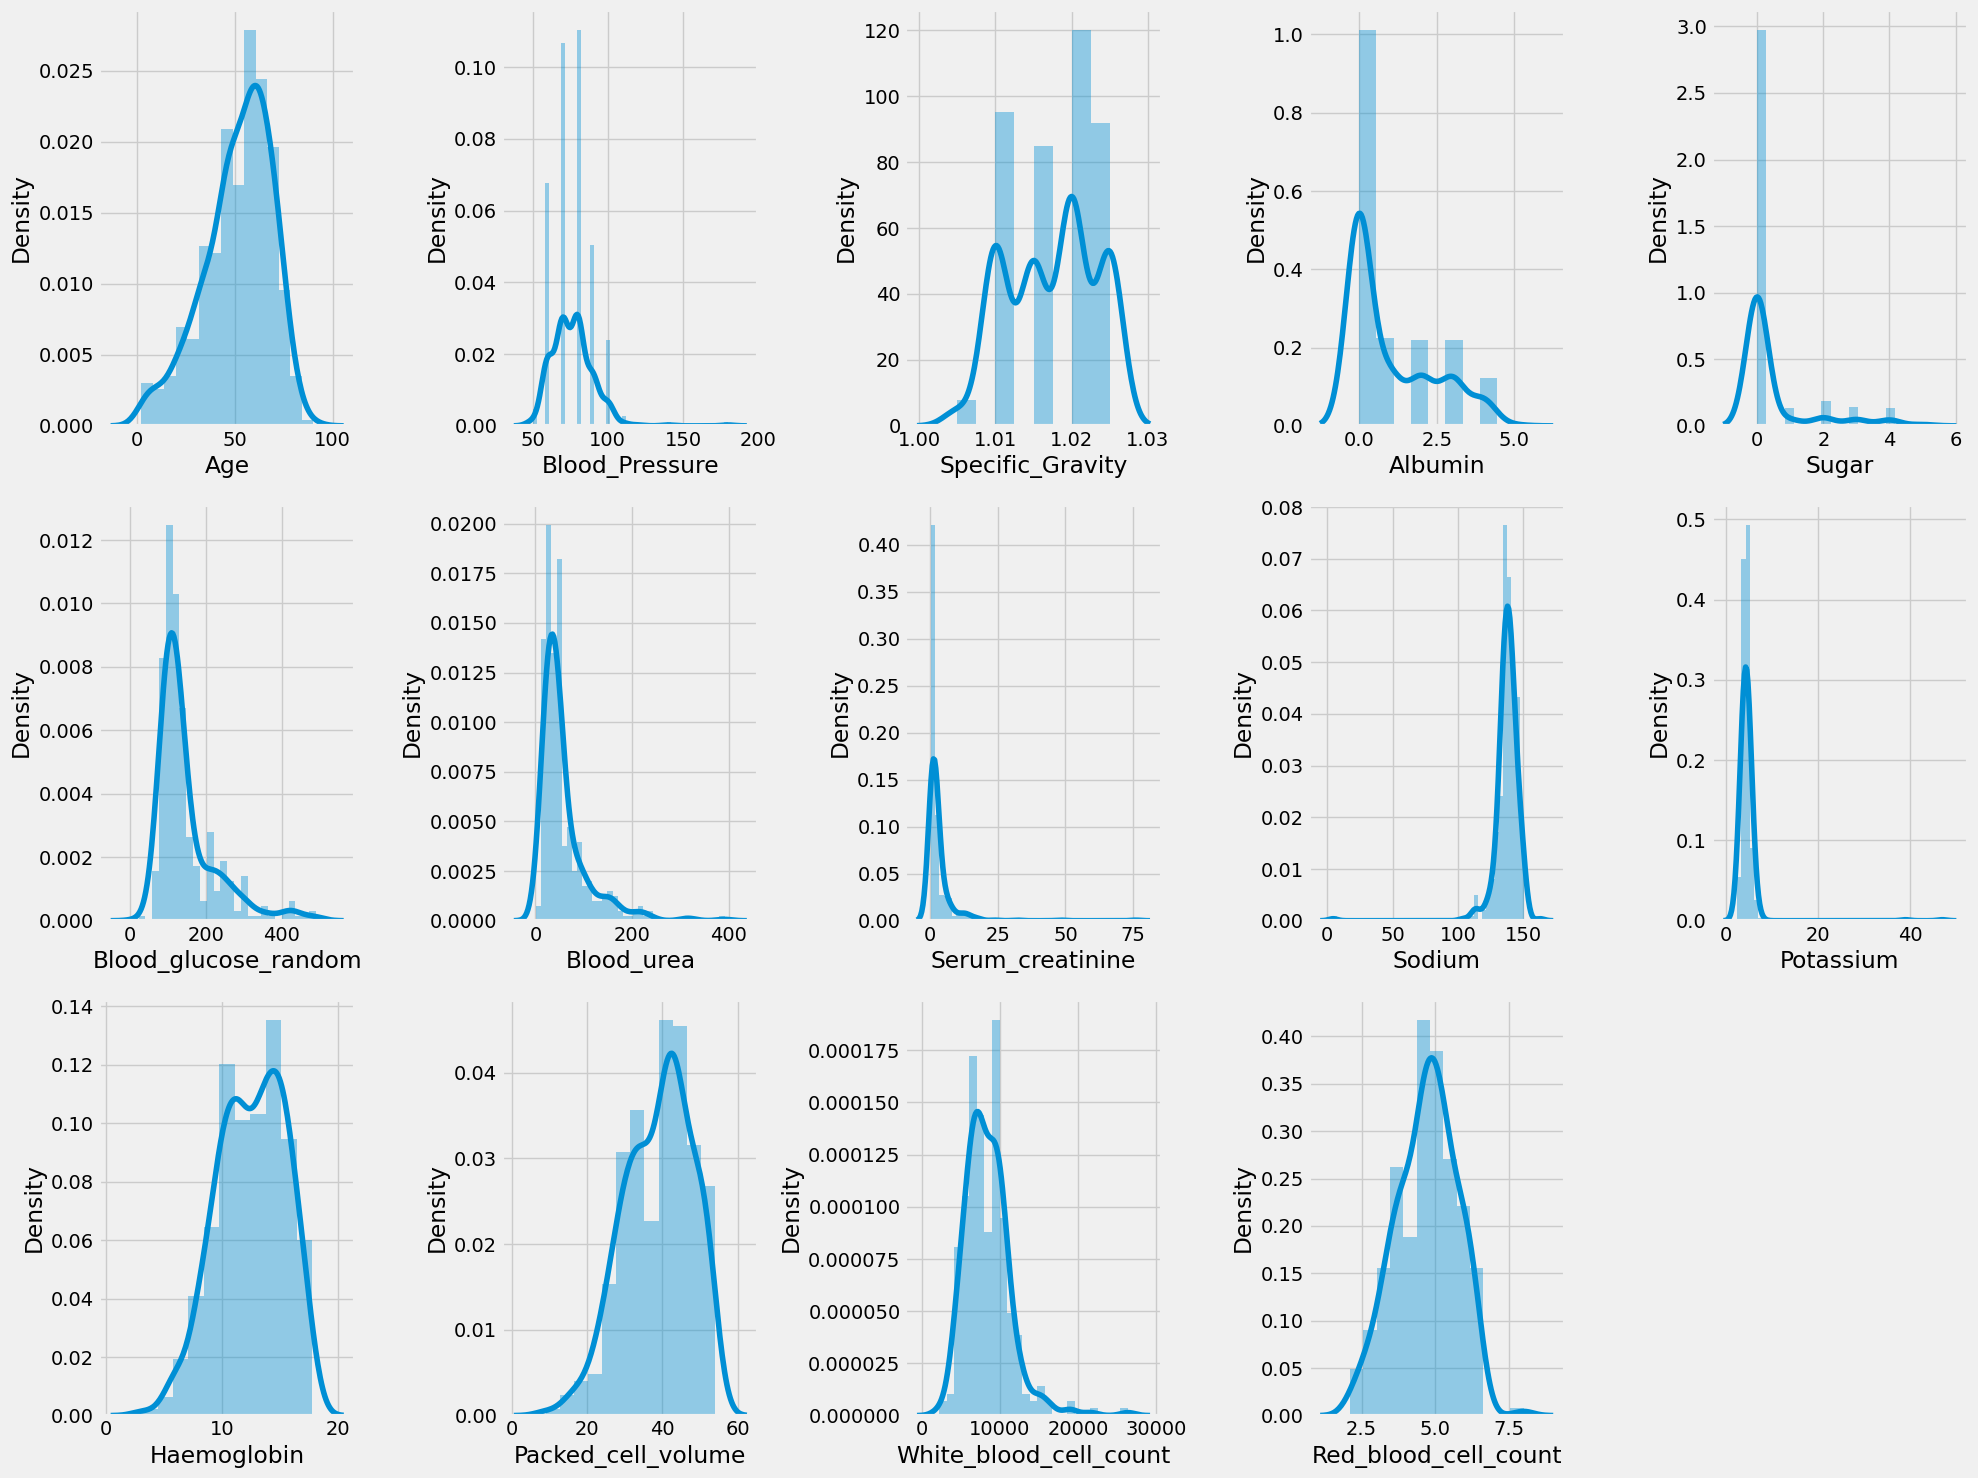

In [ ]:
#checking numerical features distribution
plt.figure(figsize = (20,15))
plotnumber = 1

for column in num_cols:
  if plotnumber <=14:
    ax = plt.subplot(3,5,plotnumber)
    sns.distplot(df[column])
    plt.xlabel(column)

  plotnumber+=1

plt.tight_layout()
plt.show()

#Skewness is present in some of the columns.

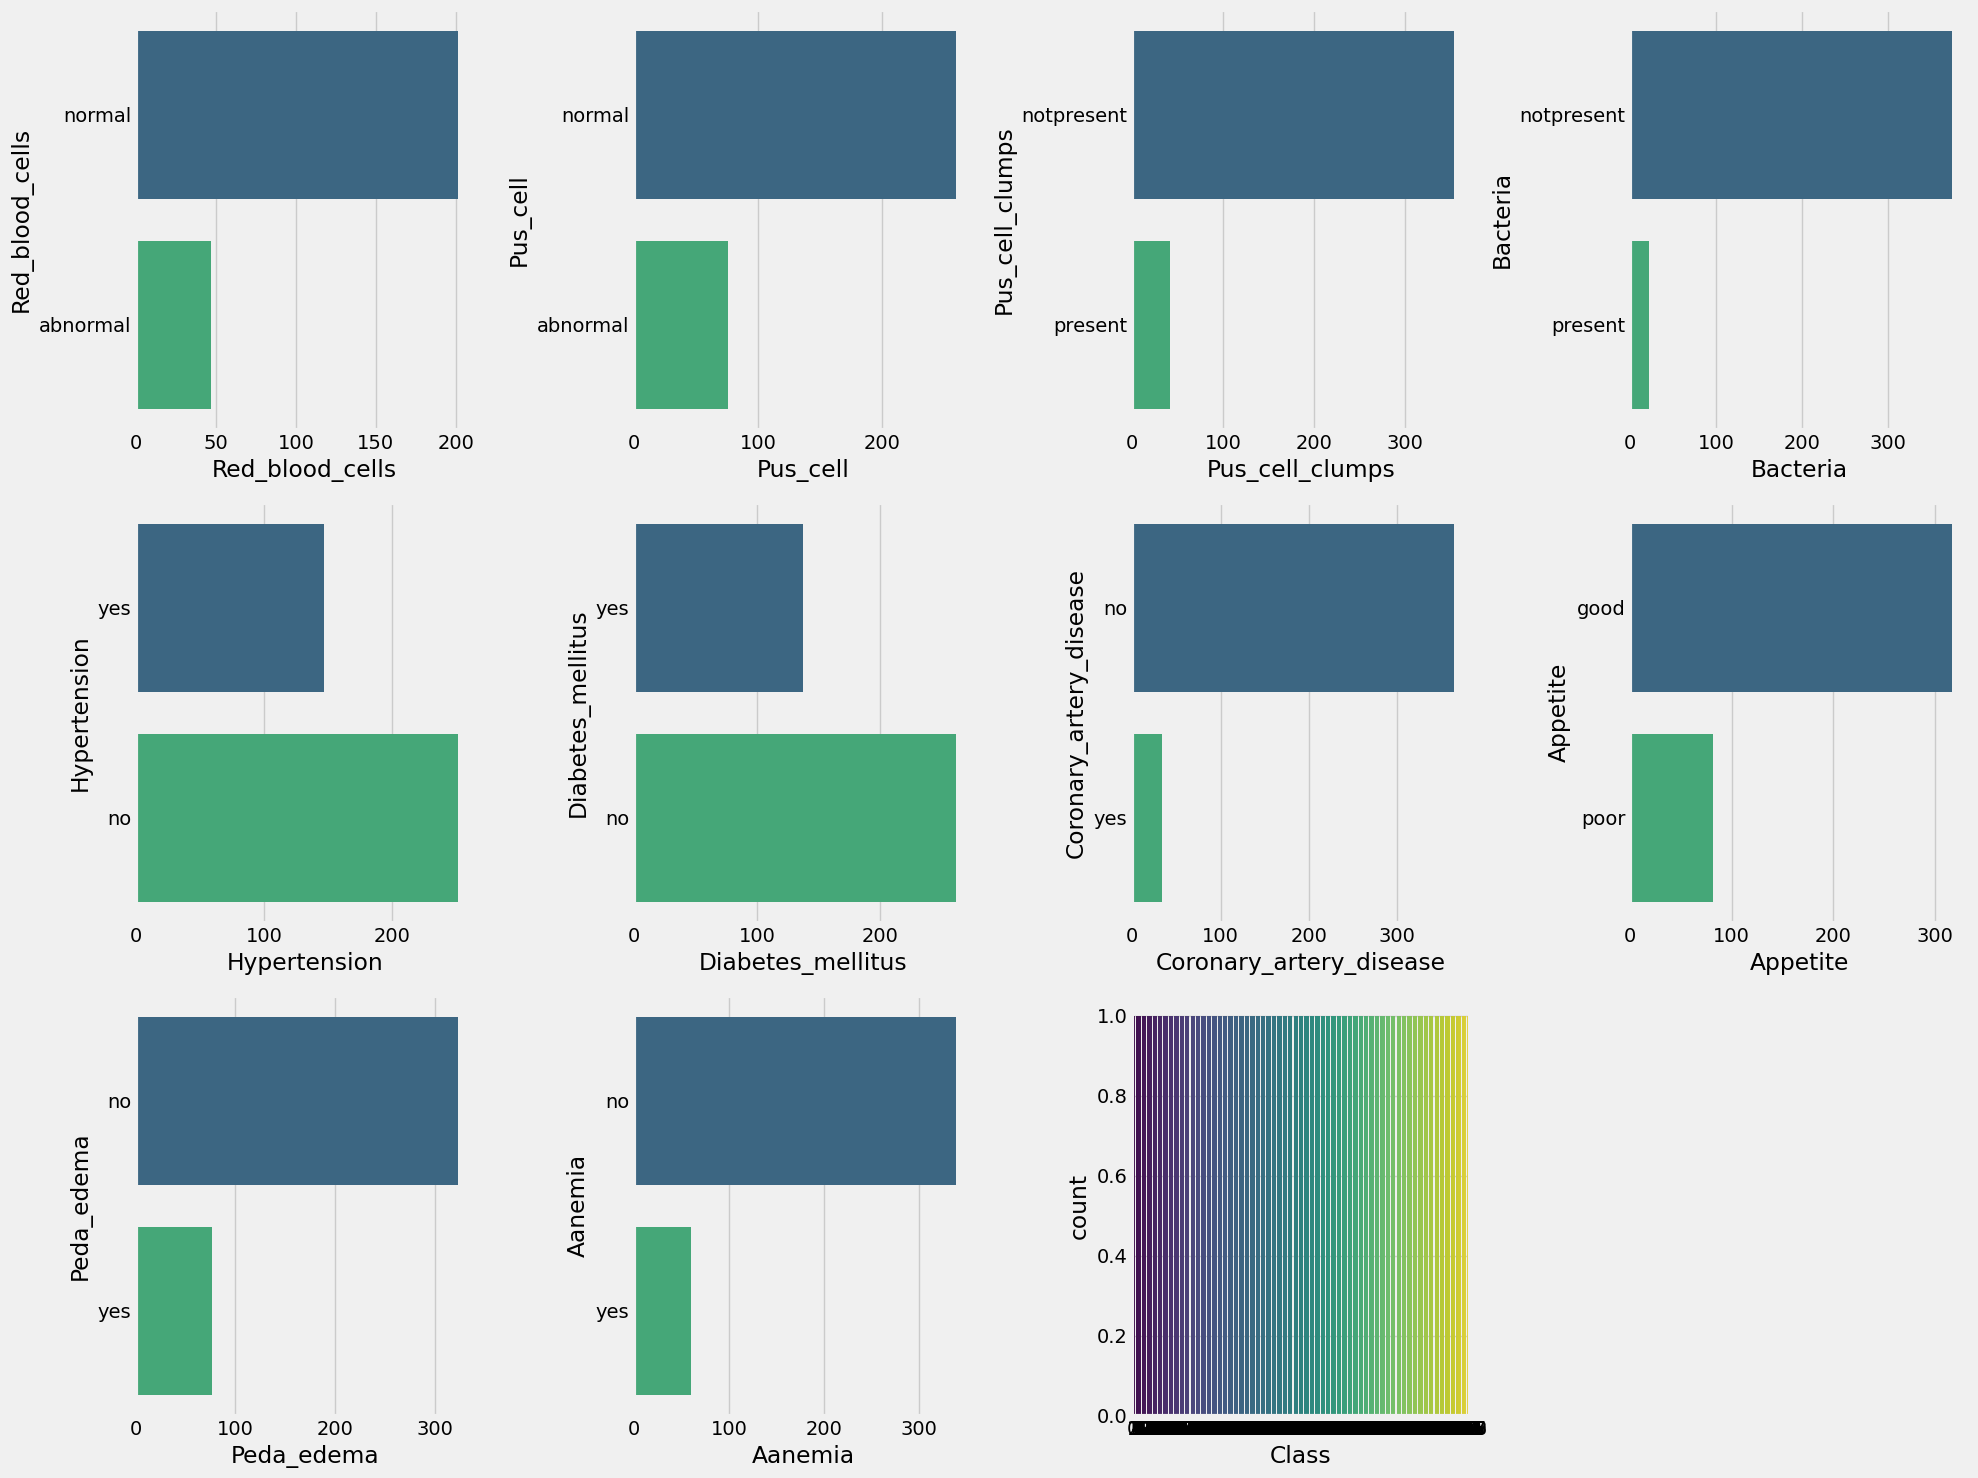

In [ ]:
#looking at categorical column
plt.figure(figsize = (20,15))
plotnumber=1

for column in cat_cols:
  if plotnumber <=11:
    ax = plt.subplot(3,4,plotnumber)
    sns.countplot(df[column] , palette="viridis")
    plt.xlabel(column)

  plotnumber+=1

plt.tight_layout()
plt.show()


In [ ]:
object_cols = df.select_dtypes(include='object').columns

df_numeric = df.drop(columns=object_cols)
correlation_matrix = df_numeric.corr()
print(correlation_matrix)

                             Age  Blood_Pressure  Specific_Gravity   Albumin  \
Age                     1.000000        0.159480         -0.191096  0.122091   
Blood_Pressure          0.159480        1.000000         -0.218836  0.160689   
Specific_Gravity       -0.191096       -0.218836          1.000000 -0.469760   
Albumin                 0.122091        0.160689         -0.469760  1.000000   
Sugar                   0.220866        0.222576         -0.296234  0.269305   
Blood_glucose_random    0.244992        0.160193         -0.374710  0.379464   
Blood_urea              0.196985        0.188517         -0.314295  0.453528   
Serum_creatinine        0.132531        0.146222         -0.361473  0.399198   
Sodium                 -0.100046       -0.116422          0.412190 -0.459896   
Potassium               0.058377        0.075151         -0.072787  0.129038   
Haemoglobin            -0.192928       -0.306540          0.602582 -0.634632   
Packed_cell_volume     -0.242119       -

<Axes: >

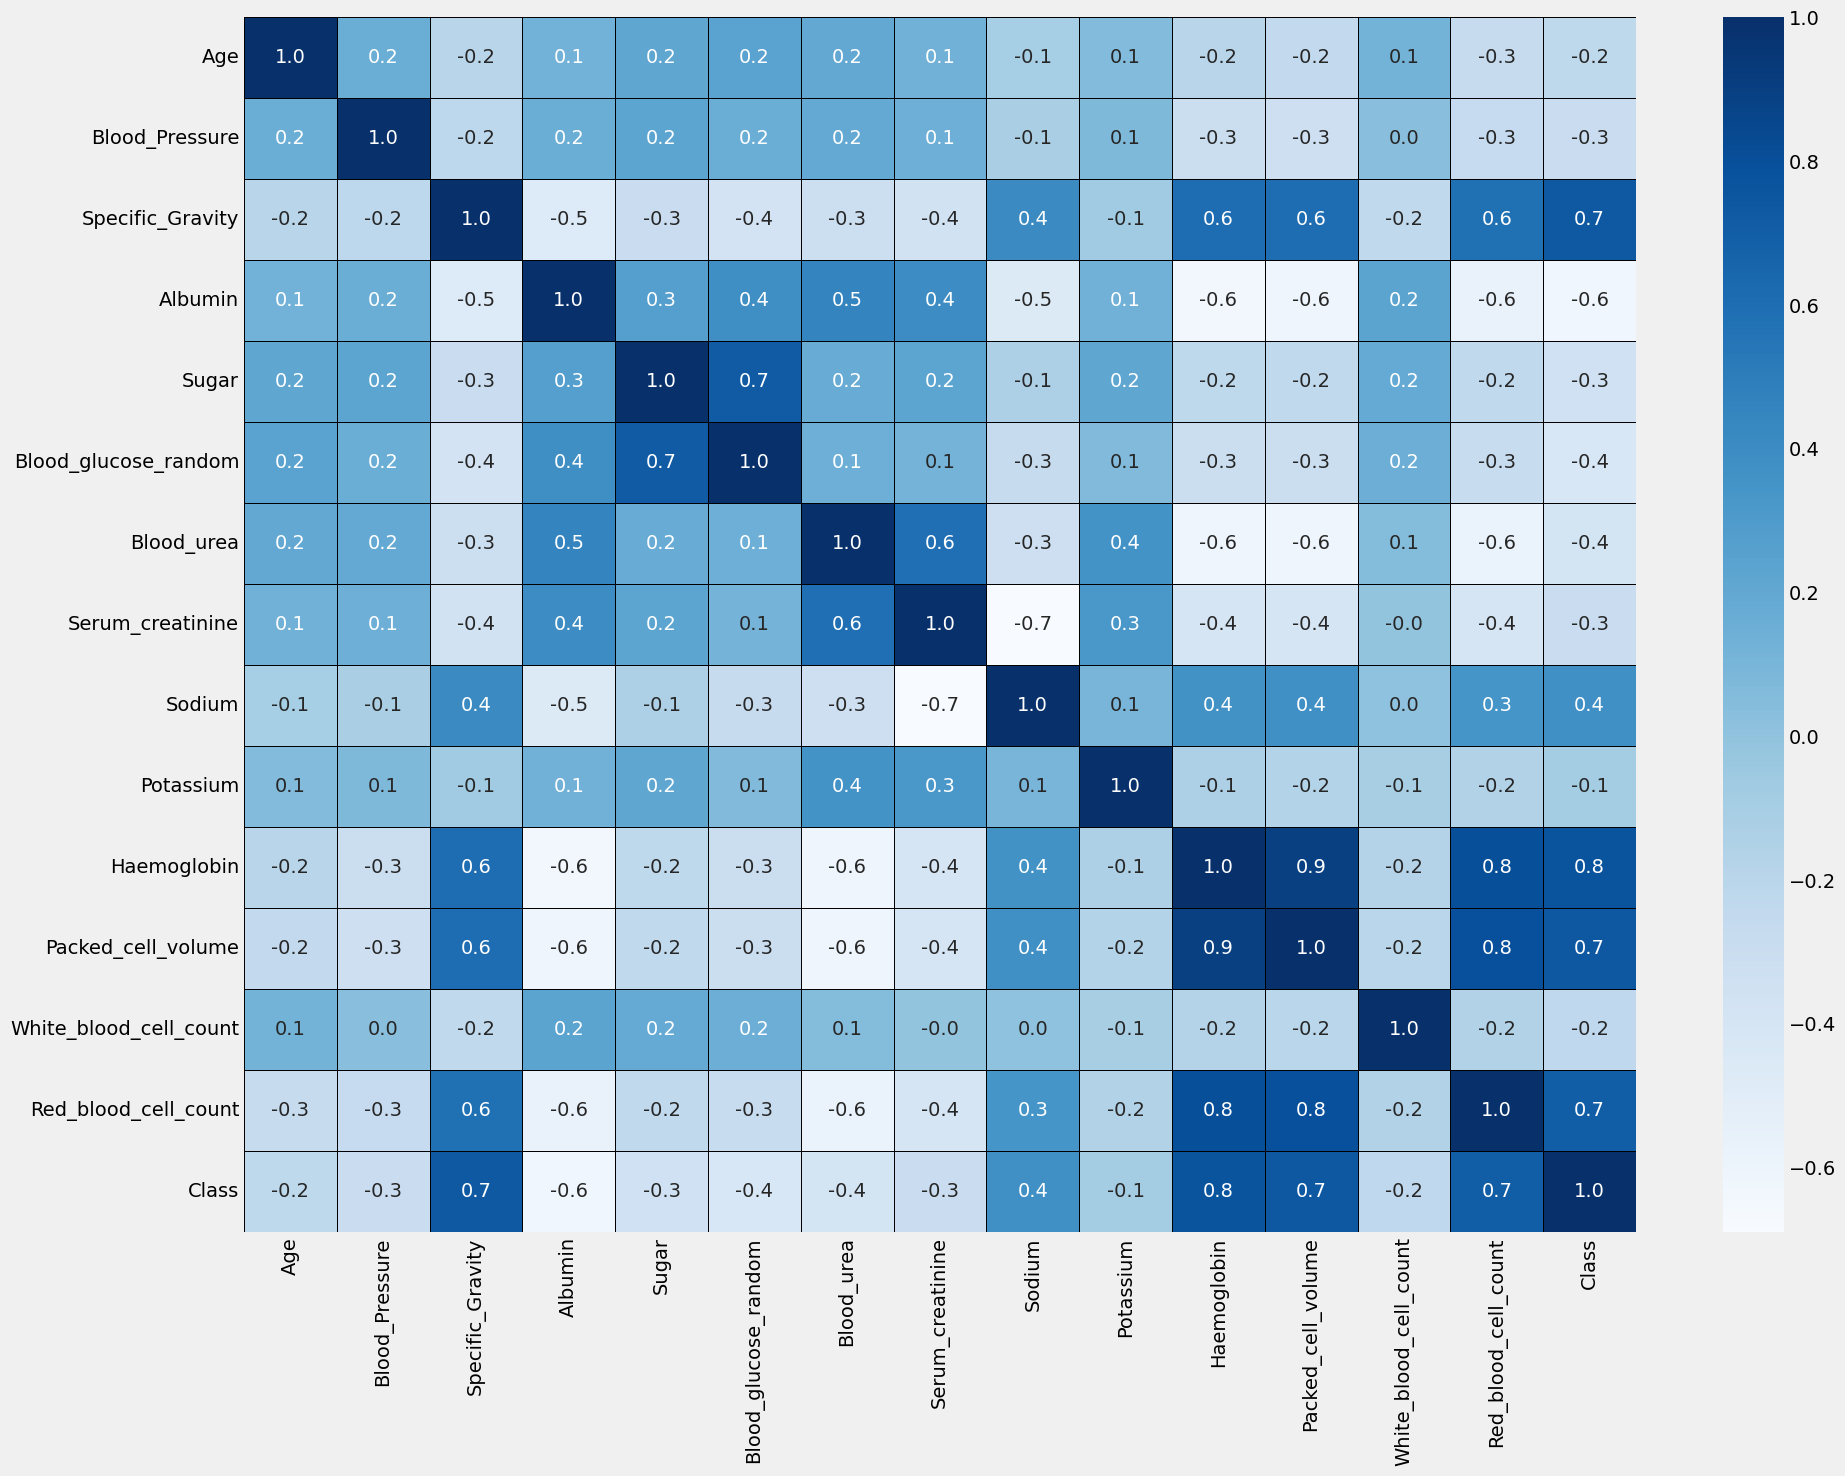

In [ ]:
plt.figure(figsize=(20,15))
sns.heatmap(correlation_matrix, annot=True  , linewidths=0.5 , fmt="0.1f", linecolor="black" , cmap="Blues")

EDA

In [ ]:
df.columns

Index(['Age', 'Blood_Pressure', 'Specific_Gravity', 'Albumin', 'Sugar',
       'Red_blood_cells', 'Pus_cell', 'Pus_cell_clumps', 'Bacteria',
       'Blood_glucose_random', 'Blood_urea', 'Serum_creatinine', 'Sodium',
       'Potassium', 'Haemoglobin', 'Packed_cell_volume',
       'White_blood_cell_count', 'Red_blood_cell_count', 'Hypertension',
       'Diabetes_mellitus', 'Coronary_artery_disease', 'Appetite',
       'Peda_edema', 'Aanemia', 'Class'],
      dtype='object')

In [ ]:
#functions to create plot
def violin(col):
  fig = px.violin(df, y=col , x="Class" , color="Class" , box=True , template="plotly_dark")
  return fig.show()

def kde(col):
    grid = sns.FacetGrid(df, hue="Class", height = 6, aspect=2)
    grid.map(sns.kdeplot, col)
    grid.add_legend()

def scatter(col1,col2):
  fig = px.scatter(df , x=col1 , y=col2 , color="Class", template="plotly_dark")
  return fig.show()

In [ ]:
violin("Red_blood_cell_count")
#patients with the kidney disease have more red blood cell count.
## 0 ..have
## 1 .. dont

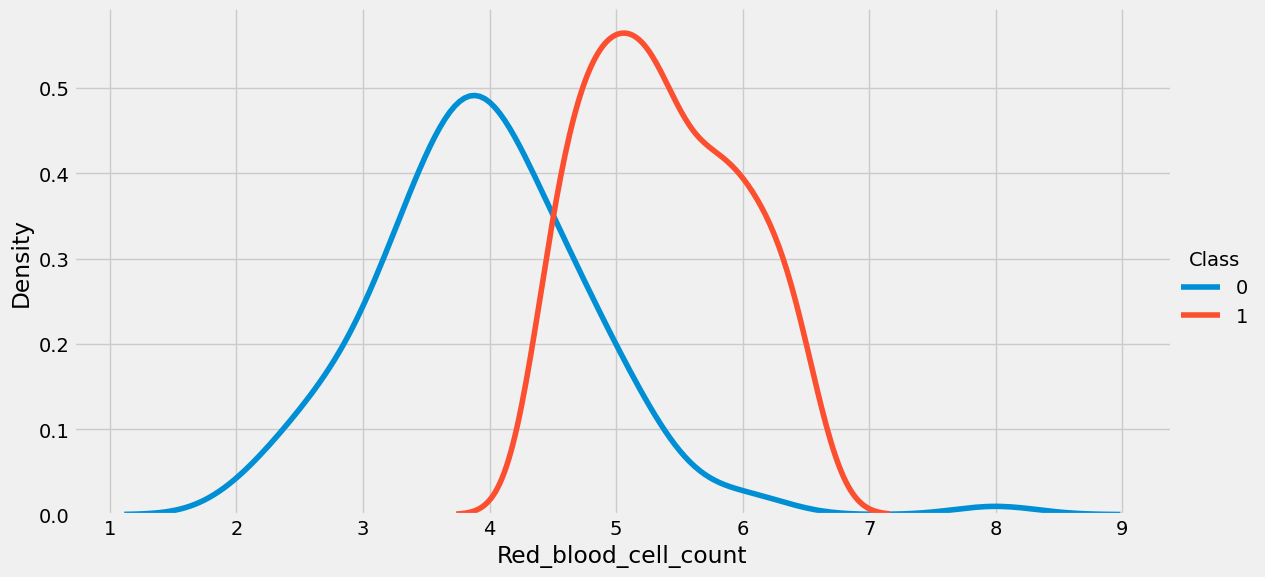

In [ ]:
kde("Red_blood_cell_count")

In [ ]:
violin("White_blood_cell_count")
#more white blood for patients.

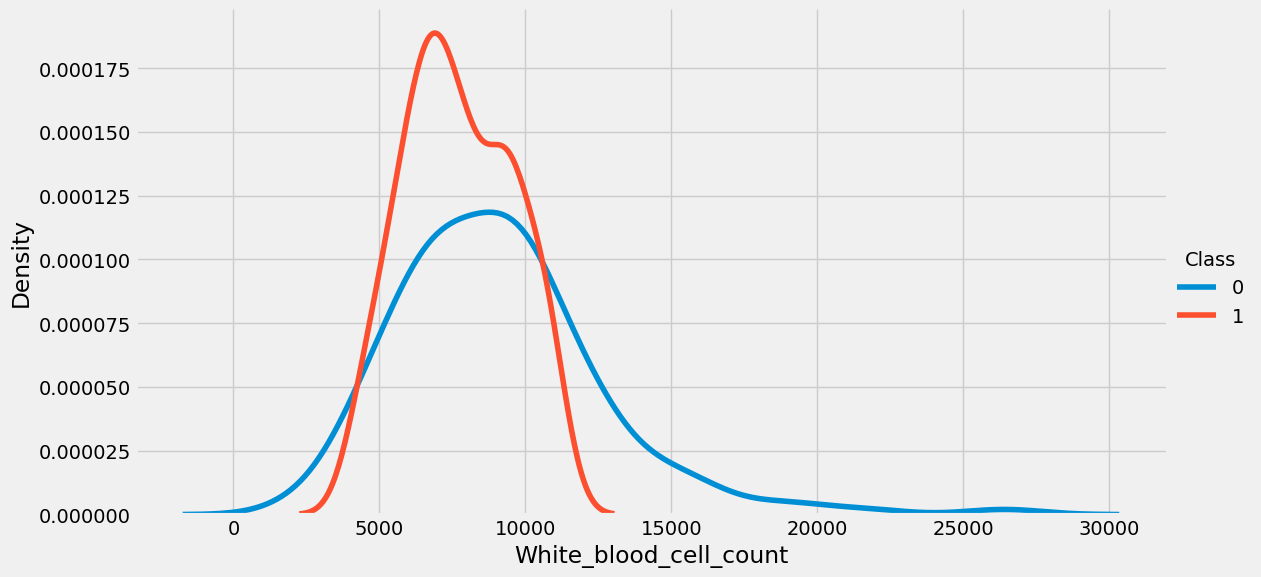

In [ ]:
kde("White_blood_cell_count")

In [ ]:
violin("Packed_cell_volume")
# patients have less packed cell volume

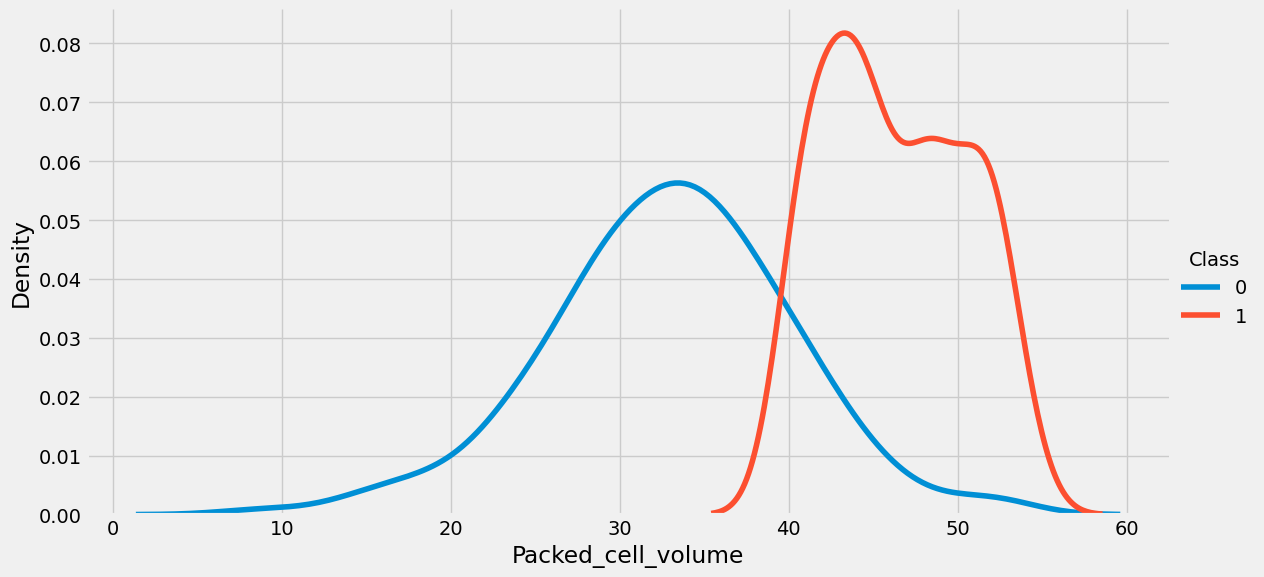

In [ ]:
kde("Packed_cell_volume")

In [ ]:
violin("Haemoglobin")
#less haemoglobin

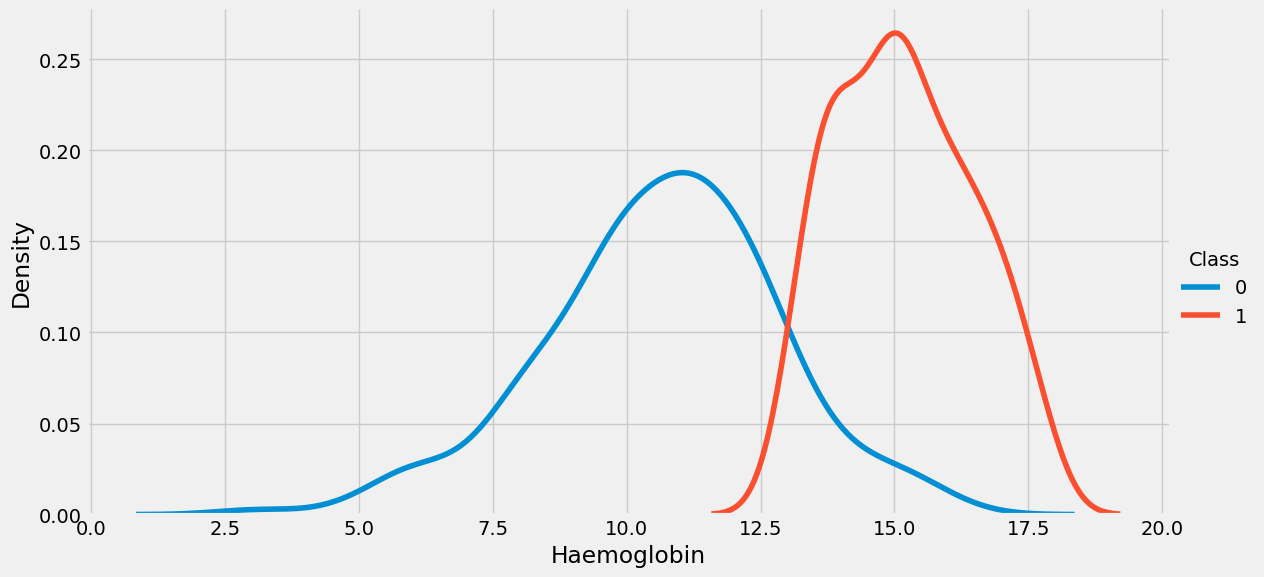

In [ ]:
kde("Haemoglobin")

In [ ]:
violin("Albumin")
#High albumin

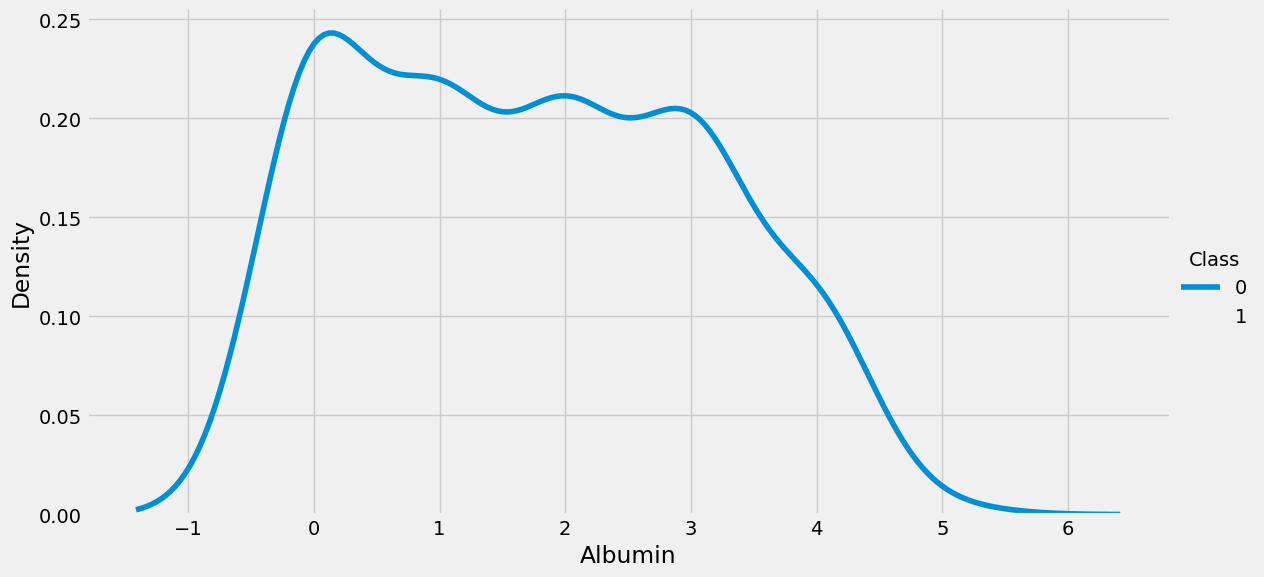

In [ ]:
kde("Albumin")

In [ ]:
violin("Blood_glucose_random")
#more complicated it depends on his general health condition

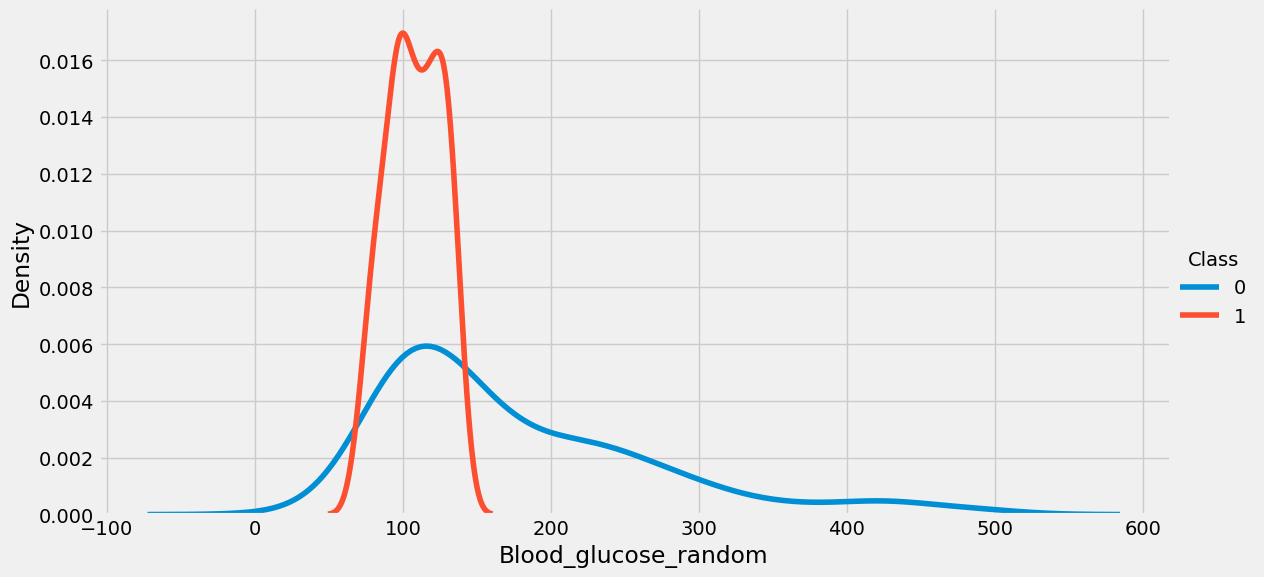

In [ ]:
kde("Blood_glucose_random")

In [ ]:
violin("Sodium")
#بيقل الصوديوم في حالات قليله

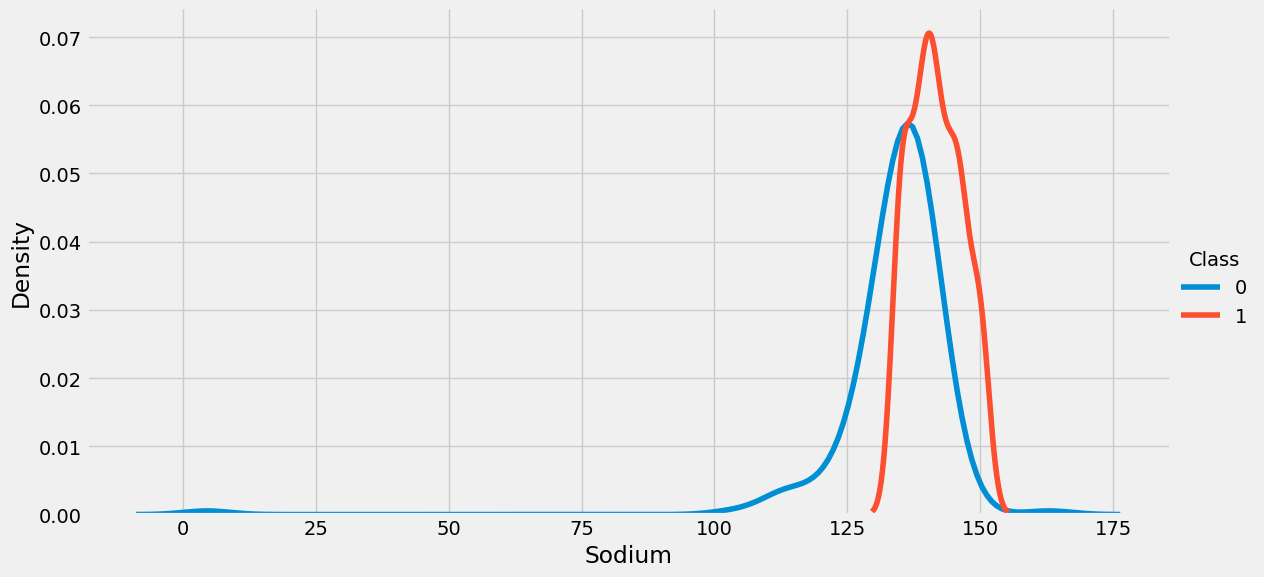

In [ ]:
kde("Sodium")

In [ ]:
violin("Blood_urea")
#high

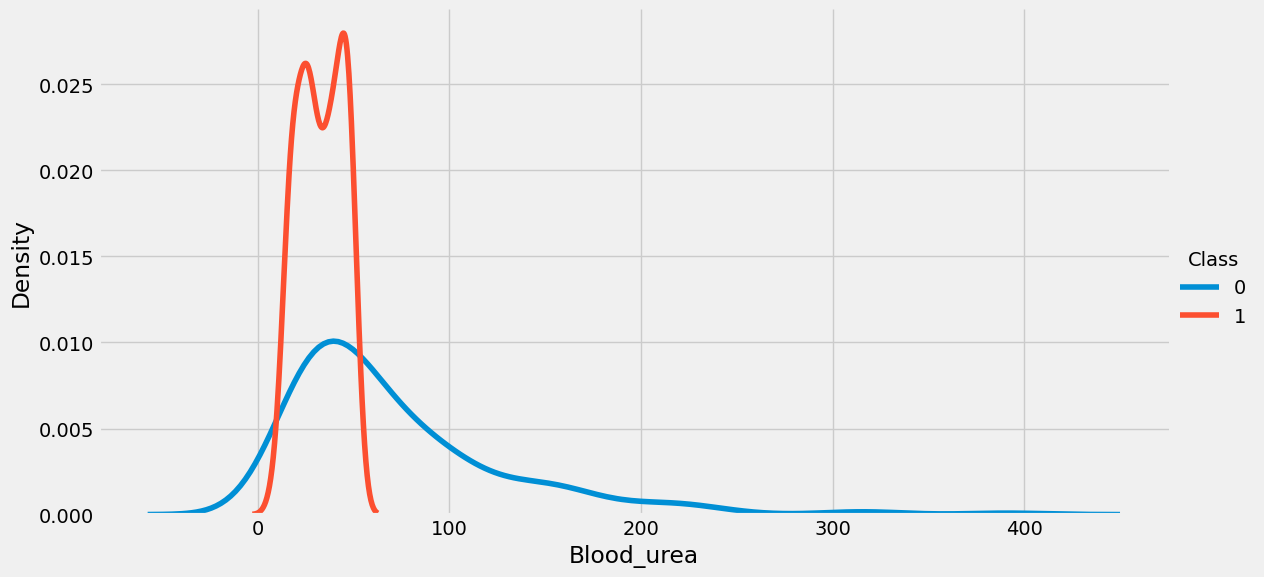

In [ ]:
kde("Blood_urea")

In [ ]:
violin("Specific_Gravity")
#بتزيد او بتقل في حالات معينه
#but in total less than normal

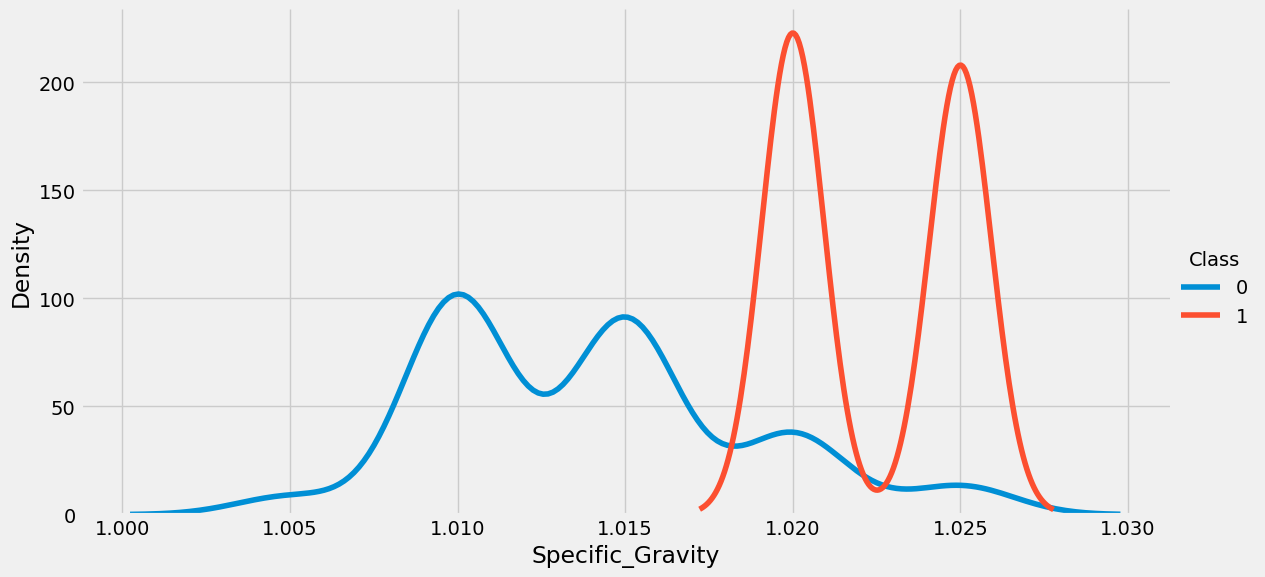

In [ ]:
kde("Specific_Gravity")

In [ ]:
scatter ("Haemoglobin" , "Packed_cell_volume")
# في توازن نوعا ما عند الانسان الطبيعي ما بين الهيموجلوبين و الخلايا  بمعدل عالي
#عند مريض الكلي بيقلو الاتنين

In [ ]:
scatter ("Red_blood_cell_count" , "Packed_cell_volume")

In [ ]:
scatter("Red_blood_cell_count" , "Albumin")
#الشخص الطبيعي عندو معدل ثابت في زياده كرات الدم الحمراء ..معدل طبيعي ..و معدل الالبومين منخفض جدا لانه لا يوجد تسرب للالبومين في الدم
#المريض يعاني غالبا من ارتفاع للالبومين عن المعدل الطبيعي بسبب تسربه ف الدم

In [ ]:
scatter("Sugar" , "Blood_glucose_random")
#الشخص الطبيعي .. معدل الجلوكوز طبيعي و لا يعاني من السكر
#المريض .. يعاني من ارتفاع السكر و الجلوكوز

In [ ]:
scatter("Packed_cell_volume", "Blood_urea")
#ارتفاع مستوي اليوريا للمريض
#الشخص الطبيعي .. اليوريا منخفضه

In [ ]:
px.bar(df , x="Specific_Gravity" , y="Packed_cell_volume" , color="Class", template="plotly_dark" ,barmode="group" , height=400)
#المريض يقل عنده معدل البول الطبيعي نظرا لحالات الفشل الكلوي

In [ ]:
px.bar(df , x="Specific_Gravity" , y="Albumin" , color="Class" , barmode="group" , template="plotly_dark" , height=400)
# نسبه الالبومين بتزيد في البول للمريض بمعدل معين

In [ ]:
px.bar(df,x="Blood_Pressure" , y="Packed_cell_volume" , color="Class" , barmode="group" , template="plotly_dark" , height=400)
#ارتفاع ضغط الدم عند المريض و قله حجم الخلايا

In [ ]:
px.bar(df , x="Blood_Pressure" , y="Haemoglobin" , barmode="group" , color="Class" , template="plotly_dark" , height=400)

Data Preprocessing

In [ ]:
#checking for null values
df.isnull().sum().sum()

1012

In [ ]:
df.isnull().sum()

,0
Age,9
Blood_Pressure,12
Specific_Gravity,47
Albumin,46
Sugar,49
Red_blood_cells,152
Pus_cell,65
Pus_cell_clumps,4
Bacteria,4
Blood_glucose_random,44


In [ ]:
df.isnull().sum().sort_values(ascending=False)

,0
Red_blood_cells,152
Red_blood_cell_count,131
White_blood_cell_count,106
Potassium,88
Sodium,87
Packed_cell_volume,71
Pus_cell,65
Haemoglobin,52
Sugar,49
Specific_Gravity,47


In [ ]:
df[num_cols].isnull().sum()

,0
Age,9
Blood_Pressure,12
Specific_Gravity,47
Albumin,46
Sugar,49
Blood_glucose_random,44
Blood_urea,19
Serum_creatinine,17
Sodium,87
Potassium,88


In [ ]:
df[cat_cols].isnull().sum()

,0
Red_blood_cells,152
Pus_cell,65
Pus_cell_clumps,4
Bacteria,4
Hypertension,2
Diabetes_mellitus,2
Coronary_artery_disease,2
Appetite,1
Peda_edema,1
Aanemia,1


In [ ]:
# filling null values, we will use two methods, random sampling for higher null values and
# mean/mode sampling for lower null values
def random_value_imputation(feature):
    random_sample = df[feature].dropna().sample(df[feature].isna().sum())
    random_sample.index = df[df[feature].isnull()].index
    df.loc[df[feature].isnull(), feature] = random_sample

def impute_mode(feature):
  mode=df[feature].mode()[0]
  df[feature]=df[feature].fillna(mode)

In [ ]:
# filling num_cols null values using random sampling method
for col in num_cols:
  random_value_imputation(col)

In [ ]:
df[num_cols].isnull().sum()

,0
Age,0
Blood_Pressure,0
Specific_Gravity,0
Albumin,0
Sugar,0
Blood_glucose_random,0
Blood_urea,0
Serum_creatinine,0
Sodium,0
Potassium,0


In [ ]:
random_value_imputation("Red_blood_cells")
random_value_imputation("Pus_cell")

for col in cat_cols:
  impute_mode(col)


In [ ]:
df[cat_cols].isnull().sum()

,0
Red_blood_cells,0
Pus_cell,0
Pus_cell_clumps,0
Bacteria,0
Hypertension,0
Diabetes_mellitus,0
Coronary_artery_disease,0
Appetite,0
Peda_edema,0
Aanemia,0


Feature Encoding

In [ ]:
for col in cat_cols:
  print(f"{col} has {df[col].unique()} categories\n")

Red_blood_cells has ['normal' 'abnormal'] categories

Pus_cell has ['normal' 'abnormal'] categories

Pus_cell_clumps has ['notpresent' 'present'] categories

Bacteria has ['notpresent' 'present'] categories

Hypertension has ['yes' 'no'] categories

Diabetes_mellitus has ['yes' 'no'] categories

Coronary_artery_disease has ['no' 'yes'] categories

Appetite has ['good' 'poor'] categories

Peda_edema has ['no' 'yes'] categories

Aanemia has ['no' 'yes'] categories

Class has [0 1] categories



In [ ]:
#As all of the categorical columns have 2 categories we can use label encoder
from sklearn.preprocessing import LabelEncoder
la = LabelEncoder()

for col in cat_cols:
  df[col]=la.fit_transform(df[col])

In [ ]:
df.head()

,Age,Blood_Pressure,Specific_Gravity,Albumin,Sugar,Red_blood_cells,Pus_cell,Pus_cell_clumps,Bacteria,Blood_glucose_random,Blood_urea,Serum_creatinine,Sodium,Potassium,Haemoglobin,Packed_cell_volume,White_blood_cell_count,Red_blood_cell_count,Hypertension,Diabetes_mellitus,Coronary_artery_disease,Appetite,Peda_edema,Aanemia,Class
0,48.0,80.0,1.020,1.0,0.0,1,1,0,0,121.0,36.0,1.2,135.0,3.5,15.4,44.0,7800.0,5.2,1,1,0,0,0,0,0
1,7.0,50.0,1.020,4.0,0.0,1,1,0,0,76.0,18.0,0.8,141.0,4.1,11.3,38.0,6000.0,2.9,0,0,0,0,0,0,0
2,62.0,80.0,1.010,2.0,3.0,1,1,0,0,423.0,53.0,1.8,131.0,4.3,9.6,31.0,7500.0,3.9,0,1,0,1,0,1,0
3,48.0,70.0,1.005,4.0,0.0,1,0,1,0,117.0,56.0,3.8,111.0,2.5,11.2,32.0,6700.0,3.9,1,0,0,1,1,1,0
4,51.0,80.0,1.010,2.0,0.0,1,1,0,0,106.0,26.0,1.4,139.0,3.8,11.6,35.0,7300.0,4.6,0,0,0,0,0,0,0


Model Building

In [ ]:
x = df.drop("Class",axis=1)
y=df["Class"]

In [ ]:
from sklearn.model_selection import train_test_split
x_train , x_test , y_train , y_test =train_test_split(x,y,test_size=0.2 , random_state=30)

KNN

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score , classification_report , confusion_matrix

In [ ]:
knn=KNeighborsClassifier()
knn.fit(x_train , y_train)

KNeighborsClassifier()

In [ ]:
knn_acc=accuracy_score(y_test , knn.predict(x_test))
print(f"Traning Accuracy of Knn is {accuracy_score(y_train , knn.predict(x_train))}")
print(f"Testing Accuracy of Knn is {knn_acc}")
print(f"Classification Report of Knn is \n{classification_report(y_test , knn.predict(x_test))}")

Traning Accuracy of Knn is 0.7875
Testing Accuracy of Knn is 0.5375
Classification Report of Knn is 
              precision    recall  f1-score   support

           0       0.73      0.43      0.54        51
           1       0.42      0.72      0.53        29

    accuracy                           0.54        80
   macro avg       0.58      0.58      0.54        80
weighted avg       0.62      0.54      0.54        80



<Axes: >

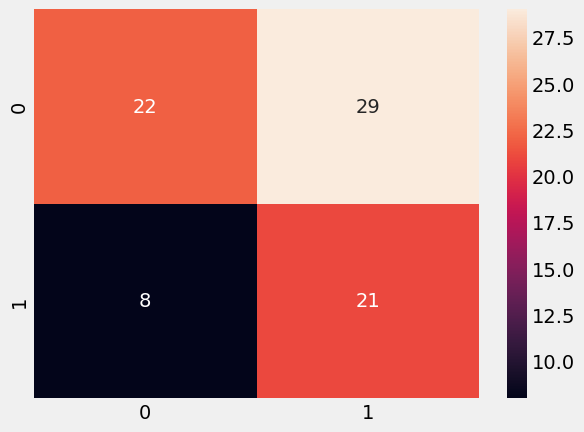

In [ ]:
sns.heatmap(confusion_matrix(y_test , knn.predict(x_test)) , annot=True )

Desion Tree Classifier

In [ ]:
from sklearn.tree import DecisionTreeClassifier

In [ ]:
dtc=DecisionTreeClassifier()
dtc.fit(x_train , y_train)

DecisionTreeClassifier()

In [ ]:
dtc_acc=accuracy_score(y_test ,dtc.predict(x_test))

In [ ]:
print(f"Training Accuracy of Decision Tree classifier is {accuracy_score(y_train ,dtc.predict(x_train))}")
print(f"Test Accuracy of Decision Tree Classifier is {dtc_acc} \n")
print(f"Classification Report of Decision Tree Classifier is \n{classification_report(y_test , dtc.predict(x_test))}")

Training Accuracy of Decision Tree classifier is 1.0
Test Accuracy of Decision Tree Classifier is 0.9375 

Classification Report of Decision Tree Classifier is 
              precision    recall  f1-score   support

           0       0.98      0.92      0.95        51
           1       0.88      0.97      0.92        29

    accuracy                           0.94        80
   macro avg       0.93      0.94      0.93        80
weighted avg       0.94      0.94      0.94        80



<Axes: >

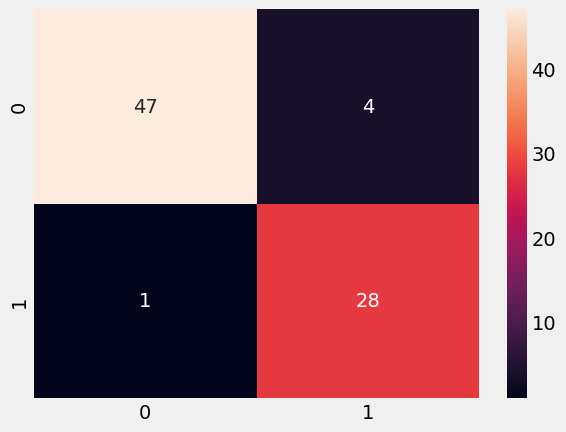

In [ ]:
sns.heatmap(confusion_matrix(y_test , dtc.predict(x_test)) , annot=True)

Random Forest Classifier

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
rfc=RandomForestClassifier()
rfc.fit(x_train , y_train)

RandomForestClassifier()

In [ ]:
rfc_acc = accuracy_score(y_test,rfc.predict(x_test))

In [ ]:
print(f"Training Accuracy of Random Forest classifier is {accuracy_score(y_train ,rfc.predict(x_train))}")
print(f"Test Accuracy of Random Forest Classifier is {rfc_acc} \n")
print(f"Classification Report of Random Forest Classifier is \n{classification_report(y_test , rfc.predict(x_test))}")

Training Accuracy of Random Forest classifier is 1.0
Test Accuracy of Random Forest Classifier is 1.0 

Classification Report of Random Forest Classifier is 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        51
           1       1.00      1.00      1.00        29

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80



<Axes: >

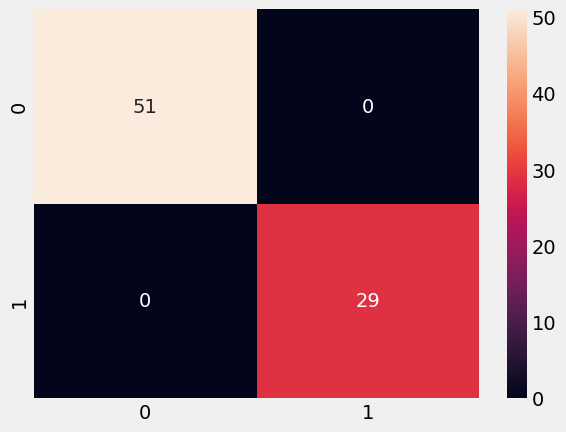

In [ ]:
sns.heatmap(confusion_matrix(y_test , rfc.predict(x_test)) , annot=True)

ADA Boost Classifier

In [ ]:
from sklearn.ensemble import AdaBoostClassifier

In [ ]:
ada=AdaBoostClassifier()
ada.fit(x_train , y_train)

AdaBoostClassifier()

In [ ]:
ada_acc=accuracy_score(y_test , ada.predict(x_test))

In [ ]:
print(f"Training Accuracy of ADA classifier is {accuracy_score(y_train ,ada.predict(x_train))}")
print(f"Test Accuracy of ADA Classifier is {ada_acc} \n")
print(f"Classification Report of ADA Classifier is \n{classification_report(y_test , ada.predict(x_test))}")

Training Accuracy of ADA classifier is 1.0
Test Accuracy of ADA Classifier is 0.9875 

Classification Report of ADA Classifier is 
              precision    recall  f1-score   support

           0       1.00      0.98      0.99        51
           1       0.97      1.00      0.98        29

    accuracy                           0.99        80
   macro avg       0.98      0.99      0.99        80
weighted avg       0.99      0.99      0.99        80



<Axes: >

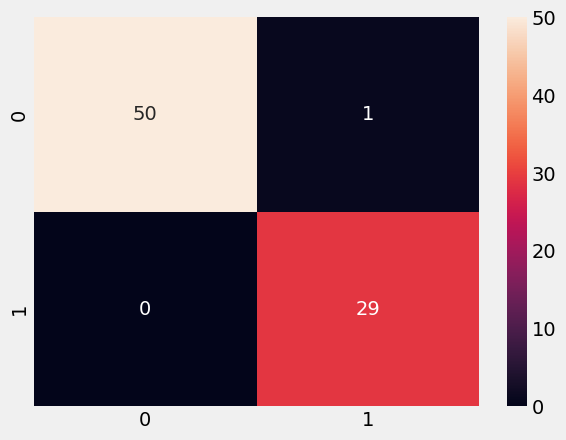

In [ ]:
sns.heatmap(confusion_matrix(y_test , ada.predict(x_test)) , annot=True)

In [ ]:
models = pd.DataFrame({ "Models":["KNN" , "Decision Tree Classifier" , "Random Forest Classifier" , "Ada Boost Classifier"],
                       "Score" :[knn_acc , dtc_acc, rfc_acc, ada_acc]})

models.sort_values(by="Score" , ascending=False)

,Models,Score
2,Random Forest Classifier,1.0000
3,Ada Boost Classifier,0.9875
1,Decision Tree Classifier,0.9375
0,KNN,0.5375


In [ ]:
px.bar(data_frame=models , x="Score" , y="Models" , color="Score" , template="plotly_dark" , height=400 , title="Model Comparison")